In [1]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# URL del archivo en el bucket público de AWS
url = "https://hybridge-education-machine-learning-datasets.s3.us-east-1.amazonaws.com/Fraud.csv"
df = pd.read_csv(url)

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
len(df)

6362620

# ¡¡¡6,362,620 OBSERVACIONES!!!

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar variables predictoras (X) y la variable a predecir (y)
# (Se eliminan columnas no numéricas o irrelevantes para este ejemplo básico)
X = df.drop(['isFraud', 'isFlaggedFraud', 'type', 'nameOrig', 'nameDest'], axis=1)
y = df['isFraud']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Datos divididos correctamente.")

# Escalar los datos (muy importante para la regresión logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Datos escalados correctamente.")

Datos divididos correctamente.
Datos escalados correctamente.


In [6]:
from sklearn.linear_model import LogisticRegression

# Crear y entrenar el modelo
modelo_logistico = LogisticRegression(max_iter=1000)
modelo_logistico.fit(X_train_scaled, y_train)

print("¡Modelo entrenado exitosamente!")

¡Modelo entrenado exitosamente!


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.91      0.42      0.57      1643

    accuracy                           1.00   1272524
   macro avg       0.95      0.71      0.79   1272524
weighted avg       1.00      1.00      1.00   1272524



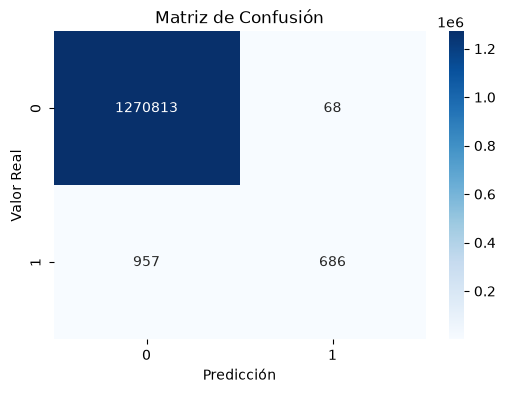

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Hacer predicciones
y_pred = modelo_logistico.predict(X_test_scaled)

# Mostrar reporte de clasificación
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# Crear Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()